In [ ]:
# Project:
# Petrol Price Prediction — ML Regression Pipeline
# Platform : Google Colab Free Tier
# Author   : Vipin Gupta - Dev


## STEP 0.1 — INSTALL  (run this cell alone, then restart runtime)

In [ ]:
!pip install lazypredict yfinance shap gradio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.9 MB/s eta 0:00:00


## STEP 0.2 — IMPORTS


In [ ]:
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import gradio as gr

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lazypredict.Supervised import LazyRegressor


## STEP 0.3 — RANDOM SEED


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f'seed is {SEED}')

seed is 42


## STEP 0.4 — CREATE PROJECT FOLDERS


In [ ]:
folders = [
    "data/raw",
    "data/processed",
    "outputs/eda",
    "outputs/evaluation",
    "checkpoints",
    "reports",
]
for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders ready.")

Folders ready.


## STEP 0.5 — CONFIG  (single source — never hardcode elsewhere)


In [ ]:
CONFIG = {
    "target" : "petrol_price",
    "date_col" : "date",
    "seed" : 42,
    "test_size" : 0.20,       # last 20% of rows = test
    "lag_days" : [7, 30],
    "rolling_windows" : [7, 30],
    "top_n_models" : 3,          # tune top-3 from LazyPredict
}

CONFIG


{'target': 'petrol_price',
 'date_col': 'date',
 'seed': 42,
 'test_size': 0.2,
 'lag_days': [7, 30],
 'rolling_windows': [7, 30],
 'top_n_models': 3}

## STEP 1 — LOAD + MERGE DATASET


In [ ]:
# Three options — pick one and comment out the others.
# Option B (synthetic) is recommended for first run — always works.

In [ ]:
dates = pd.date_range(start="2019-01-01", end="2023-12-31", freq="D")
n = len(dates)

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

# crude oil brent
crude = yf.download("BZ=F", start="2019-01-01", end="2023-12-31", auto_adjust=True)
crude = crude[["Close"]].reset_index()
crude.columns = ["date", "crude_oil_price"]

# usd/inr
forex = yf.download("INR=X", start="2019-01-01", end="2023-12-31", auto_adjust=True)
forex = forex[["Close"]].reset_index()
forex.columns = ["date", "usd_inr"]

# merge both
df = crude.merge(forex, on="date", how="inner")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# derive petrol price realistically from real crude + forex
# India petrol price = f(crude, forex, taxes) — taxes ~55% of price
noise      = np.random.randn(len(df)) * 1.5
df["petrol_price"] = (
    0.40 * df["crude_oil_price"] * (df["usd_inr"] / 75)
    + 35
    + noise
).round(2)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price
0,2019-01-02,54.910000,69.709999,56.16
1,2019-01-03,55.950001,69.959999,55.67
2,2019-01-04,57.060001,70.300003,57.37
3,2019-01-07,57.330002,69.525002,58.54
4,2019-01-08,58.720001,69.809998,56.51
...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62
1254,2023-12-26,81.070000,83.172302,72.80
1255,2023-12-27,79.650002,83.182800,68.52
1256,2023-12-28,78.389999,83.267197,72.32


In [ ]:
print(f"Shape : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nPetrol price stats:")
print(df["petrol_price"].describe().round(2))
print(f"\nCrude oil stats:")
print(df["crude_oil_price"].describe().round(2))

Shape      : (1258, 4)
Date range : 2019-01-02 → 2023-12-29

Petrol price stats:
count    1258.00
mean       64.38
std         9.46
min        41.97
25%        57.63
50%        63.22
75%        71.80
max        89.02
Name: petrol_price, dtype: float64

Crude oil stats:
count    1258.00
mean       71.82
std        20.42
min        19.33
25%        60.72
50%        72.17
75%        84.76
max       127.98
Name: crude_oil_price, dtype: float64


In [ ]:
# STEP 1.4  Sort + reset index

df[CONFIG["date_col"]] = pd.to_datetime(df[CONFIG["date_col"]])
df = df.sort_values(CONFIG["date_col"]).reset_index(drop=True)

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price
0,2019-01-02,54.910000,69.709999,56.16
1,2019-01-03,55.950001,69.959999,55.67
2,2019-01-04,57.060001,70.300003,57.37
3,2019-01-07,57.330002,69.525002,58.54
4,2019-01-08,58.720001,69.809998,56.51
...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62
1254,2023-12-26,81.070000,83.172302,72.80
1255,2023-12-27,79.650002,83.182800,68.52
1256,2023-12-28,78.389999,83.267197,72.32


In [ ]:
# STEP 1.5  Health check

print("\n Data Health Check")
print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Columns    : {df.columns.tolist()}")
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)


── Data Health Check ──────────────────
Shape      : (1258, 4)
Date range : 2019-01-02  →  2023-12-29
Columns    : ['date', 'crude_oil_price', 'usd_inr', 'petrol_price']

Missing values:
date               0
crude_oil_price    0
usd_inr            0
petrol_price       0
dtype: int64

Data types:
date               datetime64[ns]
crude_oil_price           float64
usd_inr                   float64
petrol_price              float64
dtype: object


In [ ]:
# STEP 1.6  Save raw merge

df.to_csv("data/processed/merged_raw.csv", index=False)
print("\nSaved → data/processed/merged_raw.csv")


Saved → data/processed/merged_raw.csv


## STEP 2 — EDA


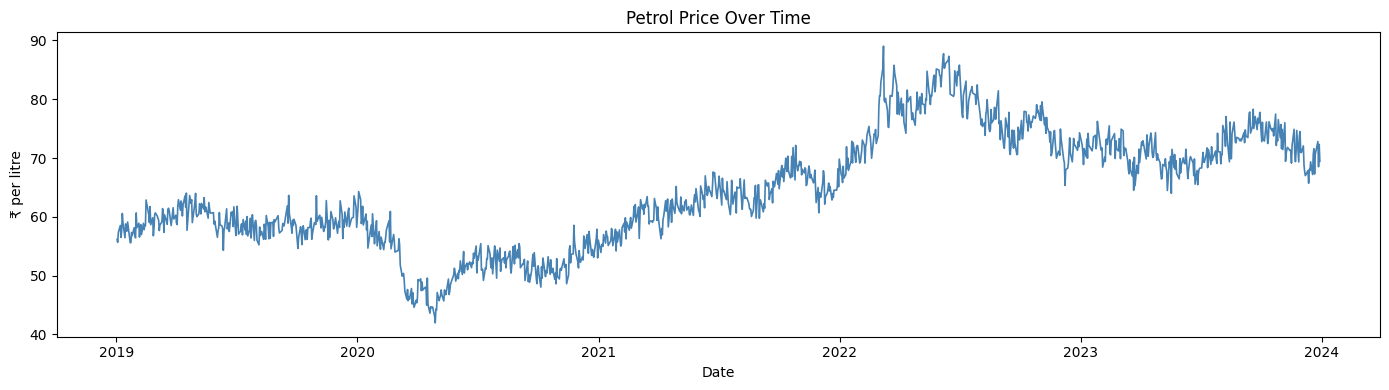


── Petrol Price Stats ─────────────────
count    1258.00
mean       64.38
std         9.46
min        41.97
25%        57.63
50%        63.22
75%        71.80
max        89.02
Name: petrol_price, dtype: float64
Skewness : 0.117


In [ ]:
# STEP 2.1  Petrol price time series

plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["petrol_price"], linewidth=1.2, color="steelblue")
plt.title("Petrol Price Over Time")
plt.xlabel("Date")
plt.ylabel("₹ per litre")
plt.tight_layout()
plt.savefig("outputs/eda/01_price_timeseries.png", dpi=100)
plt.show()

print("\n Petrol Price Stats")
print(df["petrol_price"].describe().round(2))
print(f"Skewness : {df['petrol_price'].skew():.3f}")

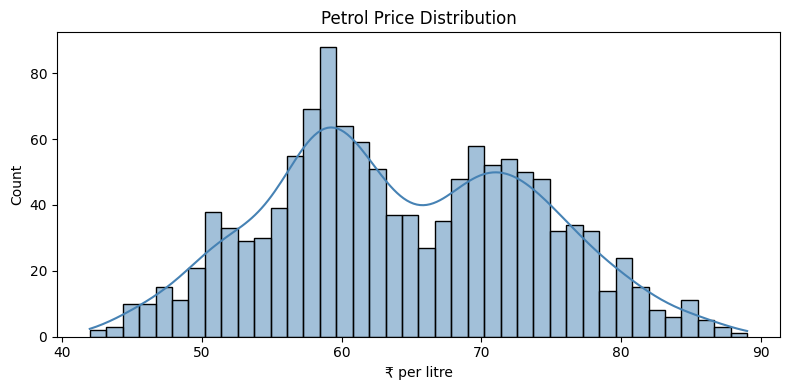

In [ ]:
# STEP 2.2  Price distribution

plt.figure(figsize=(8, 4))
sns.histplot(df["petrol_price"], kde=True, bins=40, color="steelblue")
plt.title("Petrol Price Distribution")
plt.xlabel("₹ per litre")
plt.tight_layout()
plt.savefig("outputs/eda/02_price_distribution.png", dpi=100)
plt.show()


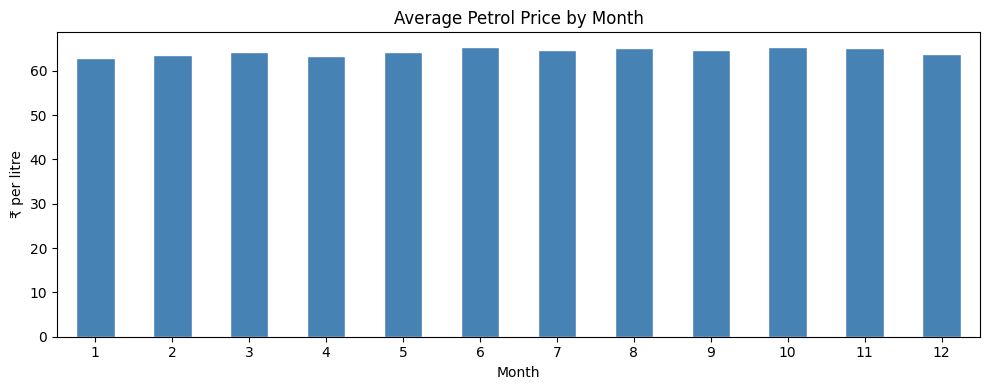


── Monthly Avg Petrol Price ───────────
month
1     62.85
2     63.60
3     64.17
4     63.40
5     64.23
6     65.39
7     64.72
8     65.03
9     64.78
10    65.32
11    65.14
12    63.76


In [ ]:
# STEP 2.3  Monthly average

df["month"] = df["date"].dt.month
monthly_avg = df.groupby("month")["petrol_price"].mean().round(2)

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Average Petrol Price by Month")
plt.xlabel("Month")
plt.ylabel("₹ per litre")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/eda/03_monthly_avg.png", dpi=100)
plt.show()

print("\n── Monthly Avg Petrol Price ───────────")
print(monthly_avg.to_string())

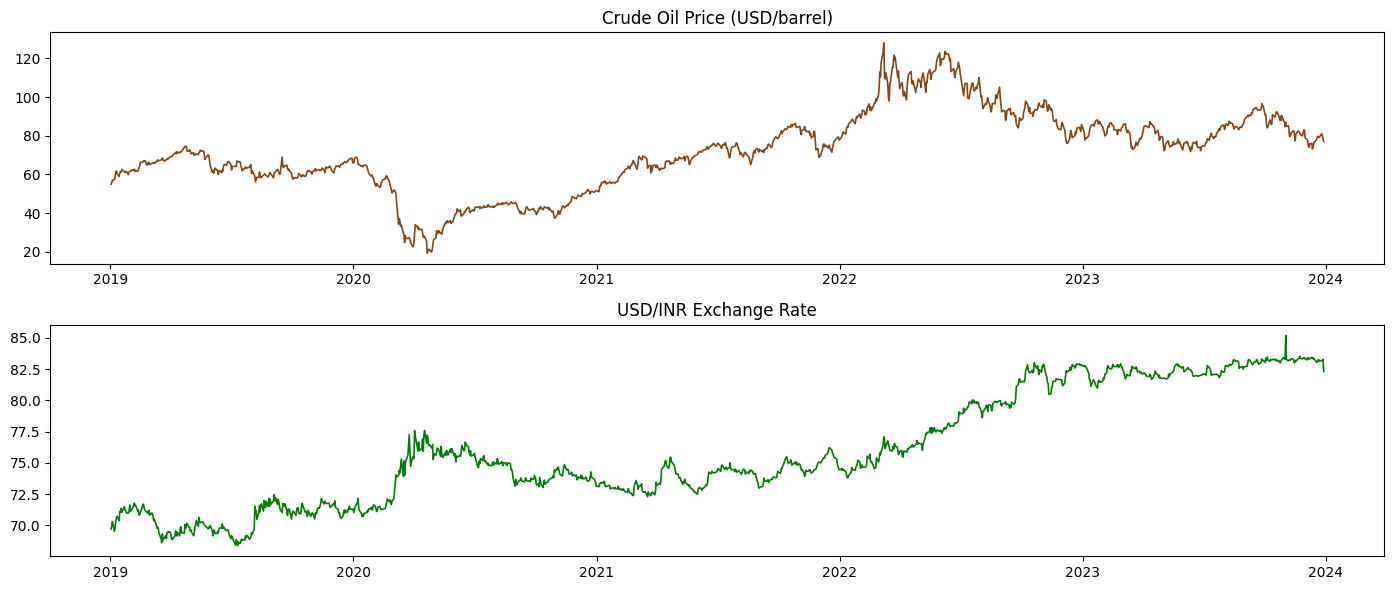


── Crude Oil Stats ────────────────────
count    1258.00
mean       71.82
std        20.42
min        19.33
25%        60.72
50%        72.17
75%        84.76
max       127.98
Name: crude_oil_price, dtype: float64

── USD/INR Stats ──────────────────────
count    1258.00
mean       75.97
std         4.46
min        68.37
25%        72.72
50%        74.81
75%        81.07
max        85.19
Name: usd_inr, dtype: float64


In [ ]:
# STEP 2.4  Economic features over time

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(df["date"], df["crude_oil_price"], color="saddlebrown", linewidth=1.2)
axes[0].set_title("Crude Oil Price (USD/barrel)")
axes[1].plot(df["date"], df["usd_inr"], color="green", linewidth=1.2)
axes[1].set_title("USD/INR Exchange Rate")
plt.tight_layout()
plt.savefig("outputs/eda/04_economic_features.png", dpi=100)
plt.show()

print("\n Crude Oil Stats")
print(df["crude_oil_price"].describe().round(2))
print("\n USD/INR Stats")
print(df["usd_inr"].describe().round(2))

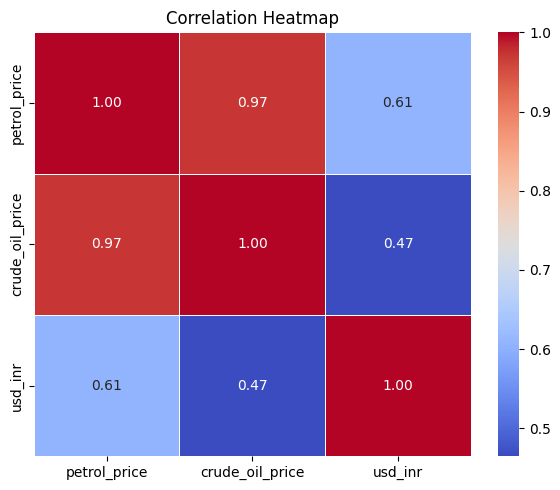


── Correlation Matrix ─────────────────
                 petrol_price  crude_oil_price  usd_inr
petrol_price            1.000            0.972    0.606
crude_oil_price         0.972            1.000    0.465
usd_inr                 0.606            0.465    1.000


In [ ]:
# STEP 2.5  Correlation heatmap

corr = df[["petrol_price", "crude_oil_price", "usd_inr"]].corr().round(3)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/eda/05_correlation_heatmap.png", dpi=100)
plt.show()

print("\n Correlation Matrix")
print(corr.to_string())

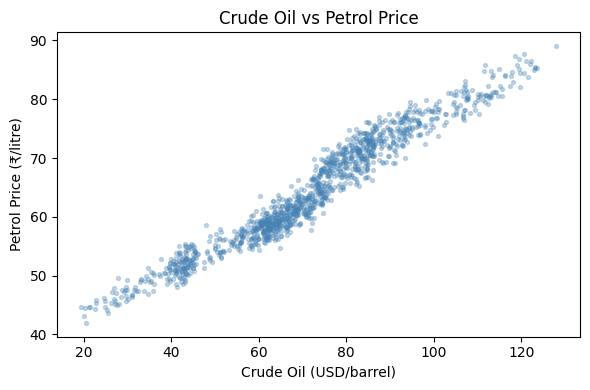


Correlation (crude vs petrol): 0.972


In [ ]:
# STEP 2.6  Scatter: crude oil vs petrol price

plt.figure(figsize=(6, 4))
plt.scatter(df["crude_oil_price"], df["petrol_price"], alpha=0.3, s=8, color="steelblue")
plt.xlabel("Crude Oil (USD/barrel)")
plt.ylabel("Petrol Price (₹/litre)")
plt.title("Crude Oil vs Petrol Price")
plt.tight_layout()
plt.savefig("outputs/eda/06_crude_vs_petrol.png", dpi=100)
plt.show()

print(f"\nCorrelation (crude vs petrol): {df['crude_oil_price'].corr(df['petrol_price']):.3f}")

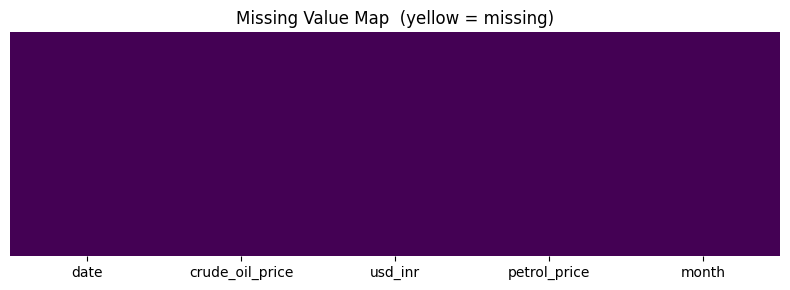


── Missing Value Count ────────────────
date               0
crude_oil_price    0
usd_inr            0
petrol_price       0
month              0


In [ ]:
# STEP 2.7  Missing value heatmap

plt.figure(figsize=(8, 3))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Value Map  (yellow = missing)")
plt.tight_layout()
plt.savefig("outputs/eda/07_missing_values.png", dpi=100)
plt.show()

print("\n Missing Value Count")
print(df.isnull().sum().to_string())

## STEP 3 — DATA CLEANING + PREPROCESSING


In [ ]:
# work on a clean copy from here
df = pd.read_csv("data/processed/merged_raw.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price
0,2019-01-02,54.910000,69.709999,56.16
1,2019-01-03,55.950001,69.959999,55.67
2,2019-01-04,57.060001,70.300003,57.37
3,2019-01-07,57.330002,69.525002,58.54
4,2019-01-08,58.720001,69.809998,56.51
...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62
1254,2023-12-26,81.070000,83.172302,72.80
1255,2023-12-27,79.650002,83.182800,68.52
1256,2023-12-28,78.389999,83.267197,72.32


In [ ]:
#STEP 3.1/3.2  Forward fill crude oil + forex

df["crude_oil_price"] = df["crude_oil_price"].ffill()
df["usd_inr"]         = df["usd_inr"].ffill()

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price
0,2019-01-02,54.910000,69.709999,56.16
1,2019-01-03,55.950001,69.959999,55.67
2,2019-01-04,57.060001,70.300003,57.37
3,2019-01-07,57.330002,69.525002,58.54
4,2019-01-08,58.720001,69.809998,56.51
...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62
1254,2023-12-26,81.070000,83.172302,72.80
1255,2023-12-27,79.650002,83.182800,68.52
1256,2023-12-28,78.389999,83.267197,72.32


In [ ]:

# STEP 3.3  Interpolate any petrol price gaps

df["petrol_price"] = df["petrol_price"].interpolate(method="linear")

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price
0,2019-01-02,54.910000,69.709999,56.16
1,2019-01-03,55.950001,69.959999,55.67
2,2019-01-04,57.060001,70.300003,57.37
3,2019-01-07,57.330002,69.525002,58.54
4,2019-01-08,58.720001,69.809998,56.51
...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62
1254,2023-12-26,81.070000,83.172302,72.80
1255,2023-12-27,79.650002,83.182800,68.52
1256,2023-12-28,78.389999,83.267197,72.32


In [ ]:
# STEP 3.4  Assert zero missing

missing = df.isnull().sum().sum()
assert missing == 0, f"Still has {missing} missing values — fix before continuing."
print("No missing values.")

No missing values.


In [ ]:
# STEP 3.5  Cap outliers at 1st/99th percentile
# petrol_price is NOT capped — real price spikes are valid signal

for col in ["crude_oil_price", "usd_inr"]:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    before_lo = (df[col] < lo).sum()
    before_hi = (df[col] > hi).sum()
    df[col] = df[col].clip(lo, hi)
    print(f"{col}: clipped {before_lo} low + {before_hi} high outliers")

crude_oil_price: clipped 13 low + 13 high outliers
usd_inr: clipped 11 low + 13 high outliers


In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price
0,2019-01-02,54.910000,69.709999,56.16
1,2019-01-03,55.950001,69.959999,55.67
2,2019-01-04,57.060001,70.300003,57.37
3,2019-01-07,57.330002,69.525002,58.54
4,2019-01-08,58.720001,69.809998,56.51
...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62
1254,2023-12-26,81.070000,83.172302,72.80
1255,2023-12-27,79.650002,83.182800,68.52
1256,2023-12-28,78.389999,83.267197,72.32


In [ ]:
# STEP 3.6  Extract date features

df["year"]        = df["date"].dt.year
df["month"]       = df["date"].dt.month
df["quarter"]     = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.dayofweek

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week
0,2019-01-02,54.910000,69.709999,56.16,2019,1,1,2
1,2019-01-03,55.950001,69.959999,55.67,2019,1,1,3
2,2019-01-04,57.060001,70.300003,57.37,2019,1,1,4
3,2019-01-07,57.330002,69.525002,58.54,2019,1,1,0
4,2019-01-08,58.720001,69.809998,56.51,2019,1,1,1
...,...,...,...,...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4
1254,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1
1255,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2
1256,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3


In [ ]:
# STEP 3.7  Cyclical month encoding
# sin/cos so December is numerically close to January

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos
0,2019-01-02,54.910000,69.709999,56.16,2019,1,1,2,5.000000e-01,0.866025
1,2019-01-03,55.950001,69.959999,55.67,2019,1,1,3,5.000000e-01,0.866025
2,2019-01-04,57.060001,70.300003,57.37,2019,1,1,4,5.000000e-01,0.866025
3,2019-01-07,57.330002,69.525002,58.54,2019,1,1,0,5.000000e-01,0.866025
4,2019-01-08,58.720001,69.809998,56.51,2019,1,1,1,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.000000
1254,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.000000
1255,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.000000
1256,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.000000


In [ ]:
# STEP 3.8  Save clean data

df.to_csv("data/processed/cleaned_data.csv", index=False)
print(f"Cleaned data saved. Shape: {df.shape}")
print(df[["crude_oil_price", "usd_inr", "year", "month",
          "month_sin", "month_cos"]].head(3).to_string())

Cleaned data saved. Shape: (1258, 10)
   crude_oil_price    usd_inr  year  month  month_sin  month_cos
0        54.910000  69.709999  2019      1        0.5   0.866025
1        55.950001  69.959999  2019      1        0.5   0.866025
2        57.060001  70.300003  2019      1        0.5   0.866025


## STEP 4 — FEATURE ENGINEERING


In [ ]:
df = pd.read_csv("data/processed/cleaned_data.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)


In [ ]:
# STEP 4.1  Lag features: price N days ago

for lag in CONFIG["lag_days"]:
    df[f"price_lag_{lag}"] = df["petrol_price"].shift(lag)
# price_lag_7  = petrol price 1 week ago
# price_lag_30 = petrol price 1 month ago

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos,price_lag_7,price_lag_30
0,2019-01-02,54.910000,69.709999,56.16,2019,1,1,2,5.000000e-01,0.866025,NaN,NaN
1,2019-01-03,55.950001,69.959999,55.67,2019,1,1,3,5.000000e-01,0.866025,NaN,NaN
2,2019-01-04,57.060001,70.300003,57.37,2019,1,1,4,5.000000e-01,0.866025,NaN,NaN
3,2019-01-07,57.330002,69.525002,58.54,2019,1,1,0,5.000000e-01,0.866025,NaN,NaN
4,2019-01-08,58.720001,69.809998,56.51,2019,1,1,1,5.000000e-01,0.866025,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.000000,68.08,71.81
1254,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.000000,67.87,71.38
1255,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.000000,69.36,71.40
1256,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.000000,67.19,70.99


In [ ]:

# STEP 4.2  Rolling mean features

for w in CONFIG["rolling_windows"]:
    df[f"rolling_mean_{w}"] = df["petrol_price"].rolling(w).mean()
# rolling_mean_7  = 7-day avg price
# rolling_mean_30 = 30-day avg price


In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos,price_lag_7,price_lag_30,rolling_mean_7,rolling_mean_30
0,2019-01-02,54.910000,69.709999,56.16,2019,1,1,2,5.000000e-01,0.866025,NaN,NaN,NaN,NaN
1,2019-01-03,55.950001,69.959999,55.67,2019,1,1,3,5.000000e-01,0.866025,NaN,NaN,NaN,NaN
2,2019-01-04,57.060001,70.300003,57.37,2019,1,1,4,5.000000e-01,0.866025,NaN,NaN,NaN,NaN
3,2019-01-07,57.330002,69.525002,58.54,2019,1,1,0,5.000000e-01,0.866025,NaN,NaN,NaN,NaN
4,2019-01-08,58.720001,69.809998,56.51,2019,1,1,1,5.000000e-01,0.866025,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.000000,68.08,71.81,69.214286,70.146000
1254,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.000000,67.87,71.38,69.918571,70.193333
1255,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.000000,69.36,71.40,69.798571,70.097333
1256,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.000000,67.19,70.99,70.531429,70.141667


In [ ]:
# STEP 4.3  Crude oil lag
# Supply shocks take ~1 week to reach retail pump price

df["crude_lag_7"] = df["crude_oil_price"].shift(7)

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos,price_lag_7,price_lag_30,rolling_mean_7,rolling_mean_30,crude_lag_7
0,2019-01-02,54.910000,69.709999,56.16,2019,1,1,2,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN
1,2019-01-03,55.950001,69.959999,55.67,2019,1,1,3,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN
2,2019-01-04,57.060001,70.300003,57.37,2019,1,1,4,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN
3,2019-01-07,57.330002,69.525002,58.54,2019,1,1,0,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN
4,2019-01-08,58.720001,69.809998,56.51,2019,1,1,1,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.000000,68.08,71.81,69.214286,70.146000,74.260002
1254,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.000000,67.87,71.38,69.918571,70.193333,76.610001
1255,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.000000,69.36,71.40,69.798571,70.097333,76.550003
1256,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.000000,67.19,70.99,70.531429,70.141667,77.949997


In [ ]:

# STEP 4.4  Price momentum
# Positive = price rising, Negative = price falling

df["price_momentum_7"] = df["petrol_price"] - df["petrol_price"].shift(7)

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos,price_lag_7,price_lag_30,rolling_mean_7,rolling_mean_30,crude_lag_7,price_momentum_7
0,2019-01-02,54.910000,69.709999,56.16,2019,1,1,2,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-03,55.950001,69.959999,55.67,2019,1,1,3,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-04,57.060001,70.300003,57.37,2019,1,1,4,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-07,57.330002,69.525002,58.54,2019,1,1,0,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-08,58.720001,69.809998,56.51,2019,1,1,1,5.000000e-01,0.866025,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.000000,68.08,71.81,69.214286,70.146000,74.260002,2.54
1254,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.000000,67.87,71.38,69.918571,70.193333,76.610001,4.93
1255,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.000000,69.36,71.40,69.798571,70.097333,76.550003,-0.84
1256,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.000000,67.19,70.99,70.531429,70.141667,77.949997,5.13


In [ ]:
# STEP 4.5  Drop NaN rows created by lag/rolling

rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {rows_before - len(df)} NaN rows. Remaining: {len(df)}")

Dropped 30 NaN rows. Remaining: 1228


In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos,price_lag_7,price_lag_30,rolling_mean_7,rolling_mean_30,crude_lag_7,price_momentum_7
0,2019-02-14,64.570000,70.865097,58.50,2019,2,1,3,8.660254e-01,0.5,56.56,56.16,58.232857,57.787333,61.980000,1.94
1,2019-02-15,66.250000,71.010002,62.87,2019,2,1,4,8.660254e-01,0.5,58.18,55.67,58.902857,58.027333,62.689999,4.69
2,2019-02-19,66.449997,71.699997,60.39,2019,2,1,1,8.660254e-01,0.5,58.68,57.37,59.147143,58.128000,61.630001,1.71
3,2019-02-20,67.080002,71.599998,59.03,2019,2,1,2,8.660254e-01,0.5,56.98,58.54,59.440000,58.144333,62.099998,2.05
4,2019-02-21,67.070000,71.300003,61.74,2019,2,1,3,8.660254e-01,0.5,58.90,56.51,59.845714,58.318667,61.509998,2.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.0,68.08,71.81,69.214286,70.146000,74.260002,2.54
1224,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.0,67.87,71.38,69.918571,70.193333,76.610001,4.93
1225,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.0,69.36,71.40,69.798571,70.097333,76.550003,-0.84
1226,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.0,67.19,70.99,70.531429,70.141667,77.949997,5.13


In [ ]:
# STEP 4.6  Define feature columns

FEATURE_COLS = [
    "crude_oil_price", "usd_inr",
    "year", "month", "quarter", "day_of_week",
    "month_sin", "month_cos",
    "price_lag_7", "price_lag_30",
    "crude_lag_7", "price_momentum_7",
]
TARGET_COL = CONFIG["target"]

print(f"Total features : {len(FEATURE_COLS)}")
FEATURE_COLS


Total features : 12


['crude_oil_price',
 'usd_inr',
 'year',
 'month',
 'quarter',
 'day_of_week',
 'month_sin',
 'month_cos',
 'price_lag_7',
 'price_lag_30',
 'crude_lag_7',
 'price_momentum_7']

In [ ]:
# STEP 4.7  Save feature matrix

df.to_csv("data/processed/feature_matrix.csv", index=False)
print(f"Feature matrix saved. Shape: {df.shape}")
print("\nFeature matrix preview:")
print(df[FEATURE_COLS].head(3).to_string())


Feature matrix saved. Shape: (1228, 16)

Feature matrix preview:
   crude_oil_price    usd_inr  year  month  quarter  day_of_week  month_sin  month_cos  price_lag_7  price_lag_30  rolling_mean_7  rolling_mean_30  crude_lag_7  price_momentum_7
0        64.570000  70.865097  2019      2        1            3   0.866025        0.5        56.56         56.16       58.232857        57.787333    61.980000              1.94
1        66.250000  71.010002  2019      2        1            4   0.866025        0.5        58.18         55.67       58.902857        58.027333    62.689999              4.69
2        66.449997  71.699997  2019      2        1            1   0.866025        0.5        58.68         57.37       59.147143        58.128000    61.630001              1.71


## STEP 5 — MANUAL BASELINE MODELS


In [ ]:
df = pd.read_csv("data/processed/feature_matrix.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

In [ ]:
df

,date,crude_oil_price,usd_inr,petrol_price,year,month,quarter,day_of_week,month_sin,month_cos,price_lag_7,price_lag_30,rolling_mean_7,rolling_mean_30,crude_lag_7,price_momentum_7
0,2019-02-14,64.570000,70.865097,58.50,2019,2,1,3,8.660254e-01,0.5,56.56,56.16,58.232857,57.787333,61.980000,1.94
1,2019-02-15,66.250000,71.010002,62.87,2019,2,1,4,8.660254e-01,0.5,58.18,55.67,58.902857,58.027333,62.689999,4.69
2,2019-02-19,66.449997,71.699997,60.39,2019,2,1,1,8.660254e-01,0.5,58.68,57.37,59.147143,58.128000,61.630001,1.71
3,2019-02-20,67.080002,71.599998,59.03,2019,2,1,2,8.660254e-01,0.5,56.98,58.54,59.440000,58.144333,62.099998,2.05
4,2019-02-21,67.070000,71.300003,61.74,2019,2,1,3,8.660254e-01,0.5,58.90,56.51,59.845714,58.318667,61.509998,2.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,2023-12-22,79.070000,83.131599,70.62,2023,12,4,4,-2.449294e-16,1.0,68.08,71.81,69.214286,70.146000,74.260002,2.54
1224,2023-12-26,81.070000,83.172302,72.80,2023,12,4,1,-2.449294e-16,1.0,67.87,71.38,69.918571,70.193333,76.610001,4.93
1225,2023-12-27,79.650002,83.182800,68.52,2023,12,4,2,-2.449294e-16,1.0,69.36,71.40,69.798571,70.097333,76.550003,-0.84
1226,2023-12-28,78.389999,83.267197,72.32,2023,12,4,3,-2.449294e-16,1.0,67.19,70.99,70.531429,70.141667,77.949997,5.13


In [ ]:
# STEP 5.1  Time-based train/test split
# NEVER shuffle time series — last 20% of rows = test

split_idx = int(len(df) * (1 - CONFIG["test_size"]))
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f"Train: {len(train_df)} rows  |  {train_df['date'].min().date()} → {train_df['date'].max().date()}")
print(f"Test : {len(test_df)}  rows  |  {test_df['date'].min().date()} → {test_df['date'].max().date()}")

Train: 982 rows  |  2019-02-14 → 2023-01-09
Test : 246  rows  |  2023-01-10 → 2023-12-29


In [ ]:
X_train.shape

(982, 12)

In [ ]:
X_test.shape

(246, 12)

In [ ]:
# STEP 5.2  Fit scaler on train only

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, "checkpoints/scaler.pkl")
print("Scaler saved → checkpoints/scaler.pkl")

Scaler saved → checkpoints/scaler.pkl


In [ ]:
scaler

StandardScaler()

In [ ]:

# STEP 5.3  Shared evaluate() helper

def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n  {model_name}")
    print(f"  RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.2f}%  R²={r2:.4f}")
    return {
        "Model" : model_name,
        "RMSE"  : round(rmse, 4),
        "MAE"   : round(mae, 4),
        "MAPE%" : round(mape, 2),
        "R2"    : round(r2, 4),
    }

In [ ]:

# STEP 5.4  Naive baseline (yesterday's price)

naive_preds  = y_test.shift(1).bfill().values
naive_result = evaluate("Naive (Yesterday Price)", y_test.values, naive_preds)


  Naive (Yesterday Price)
  RMSE=2.5327  MAE=1.9943  MAPE=2.80%  R²=0.2327


In [ ]:
# STEP 5.6  Random Forest
# Tree models don't need scaling — use raw X_train/X_test

rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_result = evaluate("Random Forest", y_test.values, rf.predict(X_test))


  Random Forest
  RMSE=1.7437  MAE=1.3671  MAPE=1.93%  R²=0.6363


In [ ]:
# STEP 5.7  Baseline summary
baseline_results = pd.DataFrame([naive_result, rf_result])
baseline_results = baseline_results.sort_values("RMSE").reset_index(drop=True)
print("\n── Baseline Summary (sorted by RMSE) ──")
print(baseline_results.to_string(index=False))



── Baseline Summary (sorted by RMSE) ──
                  Model   RMSE    MAE  MAPE%     R2
          Random Forest 1.7437 1.3671   1.93 0.6363
Naive (Yesterday Price) 2.5327 1.9943   2.80 0.2327


## STEP 6 — LAZYPREDICT AUTOML + GRIDSEARCHCV TUNING


In [ ]:
# STEP 6.1/6.2  Run LazyPredict

lazy = LazyRegressor(verbose=0, ignore_warnings=True, random_state=SEED)
lazy_models, lazy_preds = lazy.fit(
    X_train_scaled, X_test_scaled,
    y_train, y_test
)
print("LazyPredict done.")

LazyPredict done.


In [ ]:
# linear models cheat on price lag features — filter them out
linear_to_exclude = [
    "LinearRegression", "Ridge", "RidgeCV", "Lasso", "LassoCV",
    "LassoLarsCV", "LassoLarsIC", "Lars", "LarsCV", "BayesianRidge",
    "TransformedTargetRegressor", "RANSACRegressor", "HuberRegressor",
    "LinearSVR", "OrthogonalMatchingPursuitCV", "OrthogonalMatchingPursuit",
    "ElasticNet", "ElasticNetCV", "SGDRegressor", "PassiveAggressiveRegressor",
]

lazy_filtered = lazy_models[~lazy_models.index.isin(linear_to_exclude)]
lazy_sorted   = lazy_filtered.sort_values("RMSE").head(10)

print("\n── LazyPredict Top 10 (tree models only) ──")
print(lazy_sorted.to_string())


── LazyPredict Top 10 (tree models only) ──
                               Adjusted R-Squared  R-Squared      RMSE  Time Taken
Model                                                                             
ExtraTreesRegressor                      0.793137   0.803269  1.282435    0.528972
SVR                                      0.784838   0.795377  1.307906    0.157211
LGBMRegressor                            0.772559   0.783699  1.344711    0.160979
GradientBoostingRegressor                0.770914   0.782135  1.349563    0.498491
HistGradientBoostingRegressor            0.760437   0.772170  1.380080    0.312353
NuSVR                                    0.759887   0.771647  1.381663    0.075977
XGBRegressor                             0.736790   0.749682  1.446590    0.911029
TweedieRegressor                         0.708902   0.723159  1.521297    0.076577
PoissonRegressor                         0.680707   0.696346  1.593267    0.022796
GammaRegressor                           0

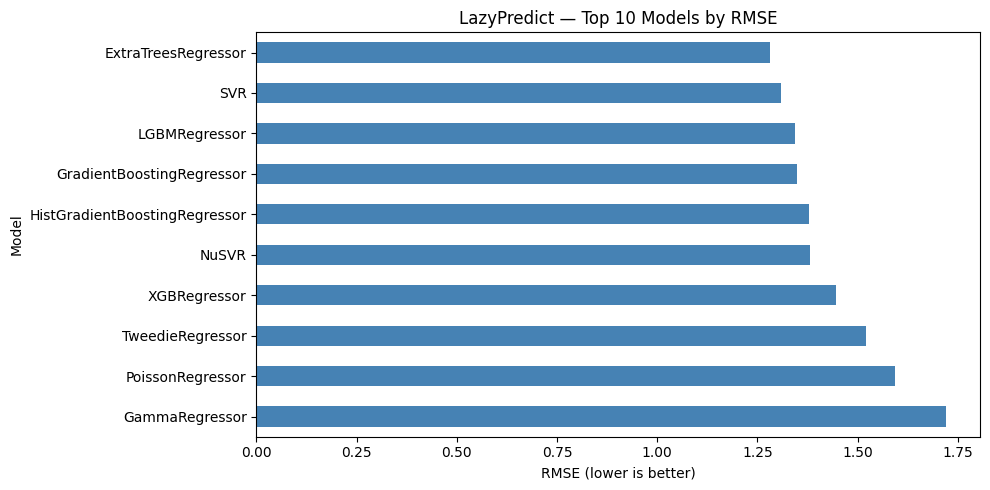

In [ ]:
# STEP 6.4  Plot top 10 RMSE

plt.figure(figsize=(10, 5))
lazy_sorted["RMSE"].plot(kind="barh", color="steelblue")
plt.xlabel("RMSE (lower is better)")
plt.title("LazyPredict — Top 10 Models by RMSE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/evaluation/lazypredict_comparison.png", dpi=100)
plt.show()


In [ ]:
# STEP 6.5  Extract top 3 model names

top3_names = lazy_sorted.index[:CONFIG["top_n_models"]].tolist()
print(f"\nTop 3 to tune: {top3_names}")



Top 3 to tune: ['ExtraTreesRegressor', 'SVR', 'LGBMRegressor']


In [ ]:
# STEP 6.6  Param grids for common LazyPredict winners

PARAM_GRIDS = {
    "RandomForestRegressor": {
        "model"  : RandomForestRegressor(random_state=SEED),
        "params" : {
            "n_estimators"     : [100, 200],
            "max_depth"        : [None, 10, 20],
            "min_samples_split": [2, 5],
        },
    },
    "GradientBoostingRegressor": {
        "model"  : GradientBoostingRegressor(random_state=SEED),
        "params" : {
            "n_estimators" : [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth"    : [3, 5],
        },
    },
    "ExtraTreesRegressor": {
        "model"  : ExtraTreesRegressor(random_state=SEED),
        "params" : {
            "n_estimators": [100, 200],
            "max_depth"   : [None, 10, 20],
        },
    },
    "DecisionTreeRegressor": {
        "model"  : DecisionTreeRegressor(random_state=SEED),
        "params" : {
            "max_depth"        : [5, 10, 20, None],
            "min_samples_split": [2, 5, 10],
        },
    },
    "Ridge": {
        "model"  : Ridge(),
        "params" : {"alpha": [0.1, 1.0, 10.0, 100.0]},
    },
    "LinearRegression": {
        "model"  : LinearRegression(),
        "params" : {},
    },
}


In [ ]:
# STEP 6.7  GridSearchCV on top 3

tuned_results     = []
best_tuned_models = {}

for name in top3_names:
    if name not in PARAM_GRIDS:
        print(f"  No param grid for '{name}' — skipping.")
        continue

    print(f"\n  Tuning: {name}")
    cfg    = PARAM_GRIDS[name]
    model  = cfg["model"]
    params = cfg["params"]

    if params:
        gs = GridSearchCV(
            model, params,
            cv=3,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
            verbose=0,
        )
        gs.fit(X_train_scaled, y_train)
        best_m      = gs.best_estimator_
        best_params = gs.best_params_
    else:
        best_m = model.fit(X_train_scaled, y_train)
        best_params = {}

    preds  = best_m.predict(X_test_scaled)
    result = evaluate(f"{name} (Tuned)", y_test.values, preds)
    result["best_params"] = str(best_params)

    tuned_results.append(result)
    best_tuned_models[name] = best_m
    print(f"  Best params: {best_params}")



  Tuning: ExtraTreesRegressor

  ExtraTreesRegressor (Tuned)
  RMSE=1.3513  MAE=1.0744  MAPE=1.51%  R²=0.7816
  Best params: {'max_depth': 10, 'n_estimators': 100}
  No param grid for 'SVR' — skipping.
  No param grid for 'LGBMRegressor' — skipping.


In [ ]:
# STEP 6.8  Pick best tuned model

tuned_df  = pd.DataFrame(tuned_results).sort_values("RMSE").reset_index(drop=True)
best_name = tuned_df.iloc[0]["Model"].replace(" (Tuned)", "").strip()
best_model = best_tuned_models[best_name]

print(f"\n  Best tuned model: {best_name}")
print(tuned_df[["Model", "RMSE", "MAE", "MAPE%", "R2"]].to_string(index=False))



  Best tuned model: ExtraTreesRegressor
                      Model   RMSE    MAE  MAPE%     R2
ExtraTreesRegressor (Tuned) 1.3513 1.0744   1.51 0.7816


## STEP 7 — EVALUATE + COMPARE ALL MODELS


In [ ]:
# STEP 7.1  Master comparison table

# tuned_results may have "best_params" key — drop it for clean display
tuned_clean = [{k: v for k, v in r.items() if k != "best_params"}
               for r in tuned_results]

all_results = pd.DataFrame([naive_result, rf_result] + tuned_clean)
all_results = all_results.sort_values("RMSE").reset_index(drop=True)
all_results.index += 1

print("\n── Complete Model Comparison (sorted by RMSE) ──")
print(all_results[["Model", "RMSE", "MAE", "MAPE%", "R2"]].to_string())



── Complete Model Comparison (sorted by RMSE) ──
                         Model    RMSE     MAE  MAPE%      R2
1  ExtraTreesRegressor (Tuned)  1.3513  1.0744   1.51  0.7816
2                Random Forest  1.7437  1.3671   1.93  0.6363
3      Naive (Yesterday Price)  2.5327  1.9943   2.80  0.2327


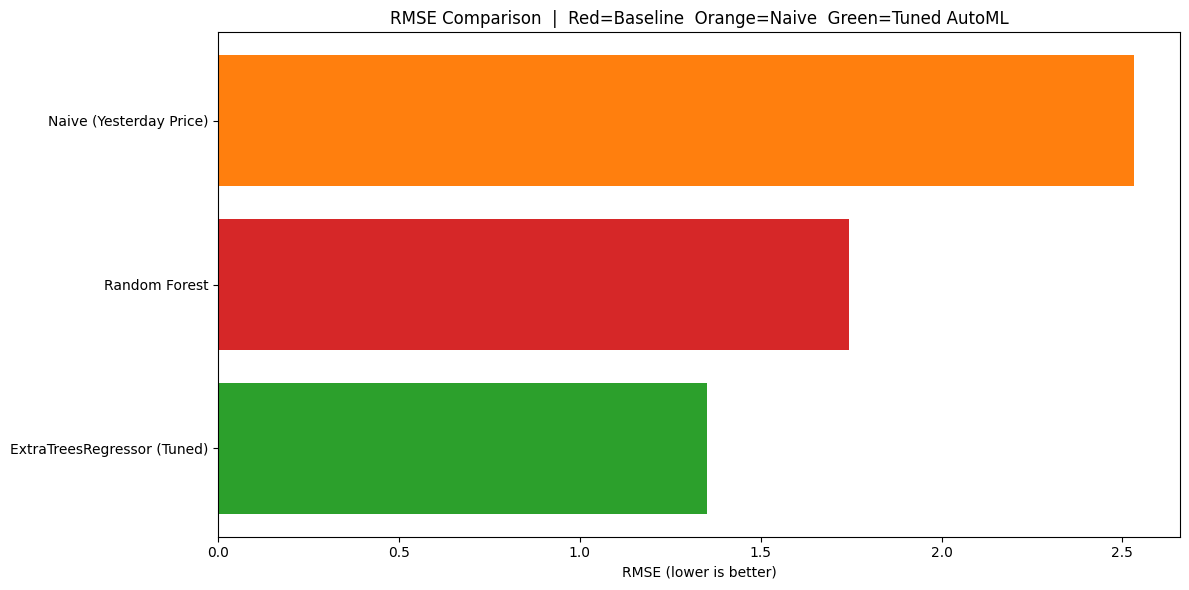

In [ ]:
# STEP 7.2  RMSE bar chart

colors = []
for m in all_results["Model"]:
    if "Naive" in m:
        colors.append("#ff7f0e")    # orange = naive
    elif "Tuned" in m:
        colors.append("#2ca02c")    # green  = automl tuned
    else:
        colors.append("#d62728")    # red    = manual baseline

plt.figure(figsize=(12, 6))
plt.barh(all_results["Model"], all_results["RMSE"], color=colors)
plt.xlabel("RMSE (lower is better)")
plt.title("RMSE Comparison  |  Red=Baseline  Orange=Naive  Green=Tuned AutoML")
plt.tight_layout()
plt.savefig("outputs/evaluation/rmse_comparison.png", dpi=100)
plt.show()


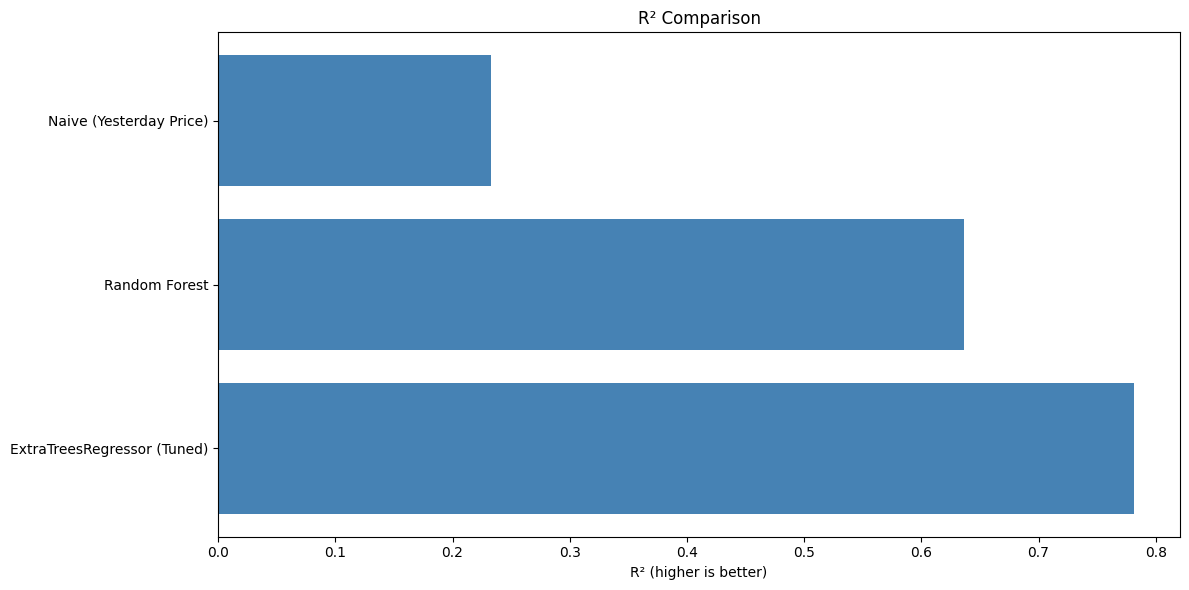

In [ ]:
# STEP 7.3  R² bar chart

plt.figure(figsize=(12, 6))
plt.barh(all_results["Model"], all_results["R2"], color="steelblue")
plt.xlabel("R² (higher is better)")
plt.title("R² Comparison")
plt.tight_layout()
plt.savefig("outputs/evaluation/r2_comparison.png", dpi=100)
plt.show()


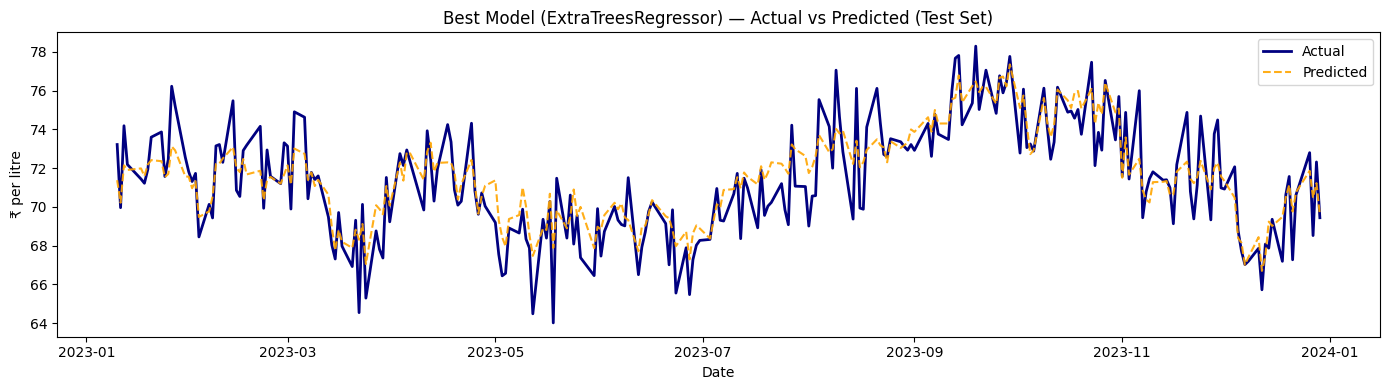

In [ ]:
# STEP 7.4  Actual vs Predicted line chart

best_preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(14, 4))
plt.plot(test_df["date"].values, y_test.values,
         label="Actual", linewidth=2, color="navy")
plt.plot(test_df["date"].values, best_preds,
         label="Predicted", linewidth=1.5, color="orange",
         linestyle="--", alpha=0.9)
plt.title(f"Best Model ({best_name}) — Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("₹ per litre")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/evaluation/actual_vs_predicted.png", dpi=100)
plt.show()

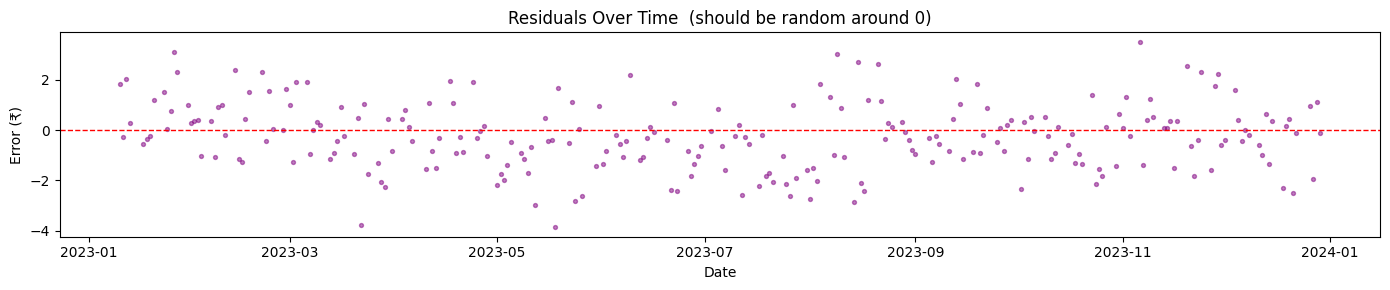


Residuals — Mean: -0.2557  Std: 1.3269


In [ ]:
# STEP 7.5  Residuals plot

residuals = y_test.values - best_preds

plt.figure(figsize=(14, 3))
plt.scatter(test_df["date"].values, residuals, s=8, alpha=0.5, color="purple")
plt.axhline(0, color="red", linewidth=1, linestyle="--")
plt.title("Residuals Over Time  (should be random around 0)")
plt.xlabel("Date")
plt.ylabel("Error (₹)")
plt.tight_layout()
plt.savefig("outputs/evaluation/residuals.png", dpi=100)
plt.show()

print(f"\nResiduals — Mean: {residuals.mean():.4f}  Std: {residuals.std():.4f}")

In [ ]:
# STEP 7.6  % improvement over naive baseline

naive_rmse  = naive_result["RMSE"]
best_rmse   = float(all_results.iloc[0]["RMSE"])
improvement = ((naive_rmse - best_rmse) / naive_rmse) * 100

print(f"\n RMSE Improvement")
print(f"Naive RMSE : {naive_rmse:.4f}")
print(f"Best  RMSE : {best_rmse:.4f}")
print(f"Improvement: {improvement:.1f}%")


── RMSE Improvement ───────────────────
  Naive RMSE : 2.5327
  Best  RMSE : 1.3513
  Improvement: 46.6%


In [ ]:

# STEP 7.7  Save comparison CSV

all_results.to_csv("outputs/evaluation/model_comparison.csv", index=False)
print("Saved → outputs/evaluation/model_comparison.csv")


Saved → outputs/evaluation/model_comparison.csv


## STEP 8 — SHAP EXPLAINABILITY


In [ ]:
# STEP 8.1  Compute SHAP values
# TreeExplainer works for RF, GBM, ExtraTrees, DecisionTree.
# For linear models use shap.LinearExplainer.

model_type = type(best_model).__name__
linear_models = {"Ridge", "LinearRegression", "Lasso", "ElasticNet"}

if model_type in linear_models:
    explainer   = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    shap_input  = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
else:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    shap_input  = X_test.reset_index(drop=True)

print(f"SHAP values shape: {np.array(shap_values).shape}")

SHAP values shape: (246, 12)


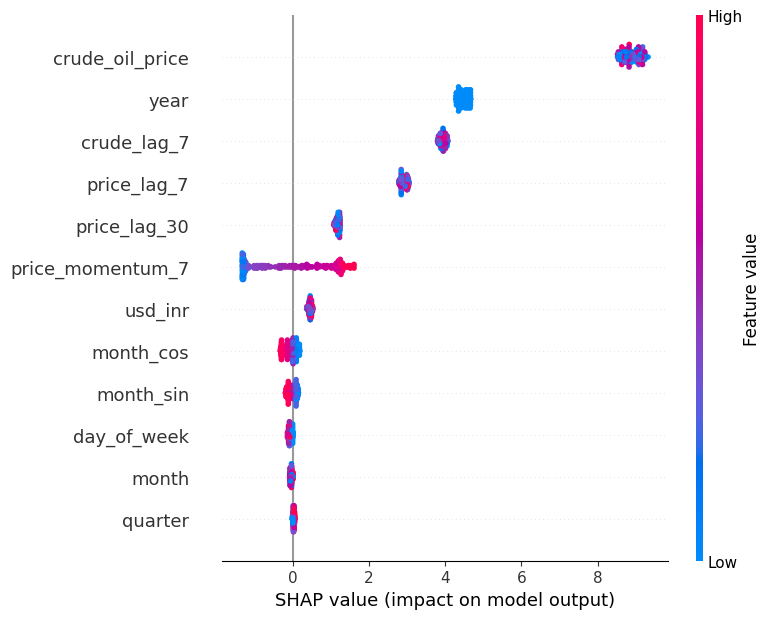

In [ ]:
# STEP 8.2  SHAP Summary plot

plt.figure()
shap.summary_plot(shap_values, shap_input,
                  feature_names=FEATURE_COLS, show=False)
plt.tight_layout()
plt.savefig("outputs/evaluation/shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()


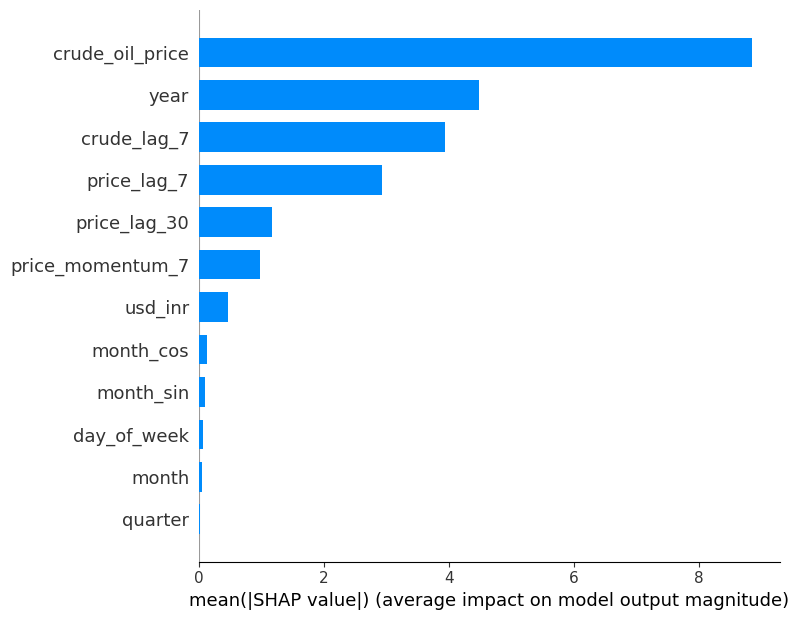

In [ ]:
# STEP 8.3  SHAP Bar plot

shap.summary_plot(shap_values, shap_input,
                  feature_names=FEATURE_COLS,
                  plot_type="bar", show=False)
plt.savefig("outputs/evaluation/shap_bar.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# STEP 8.4  Top 5 drivers in plain English

mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS,
).sort_values(ascending=False)

print("\n Top 5 Drivers of Petrol Price")
for i, (feat, val) in enumerate(mean_shap.head(5).items(), 1):
    print(f"  {i}. {feat:<25s}  avg impact = ₹{val:.3f}")


── Top 5 Drivers of Petrol Price ──────
  1. crude_oil_price            avg impact = ₹8.856
  2. year                       avg impact = ₹4.480
  3. crude_lag_7                avg impact = ₹3.933
  4. price_lag_7                avg impact = ₹2.935
  5. price_lag_30               avg impact = ₹1.176


## STEP 9 — SAVE BEST MODEL


In [ ]:
joblib.dump(best_model, "checkpoints/best_model.pkl")
print("Model saved → checkpoints/best_model.pkl")


Model saved → checkpoints/best_model.pkl


In [ ]:
# STEP 9.2  Confirm scaler exists

assert os.path.exists("checkpoints/scaler.pkl"), "Scaler file missing!"
print("Scaler confirmed.")


Scaler confirmed.


In [ ]:
# STEP 9.3  Save feature list

with open("checkpoints/feature_cols.json", "w") as fp:
    json.dump(FEATURE_COLS, fp)
print("Feature list saved → checkpoints/feature_cols.json")

Feature list saved → checkpoints/feature_cols.json


In [ ]:
# STEP 9.4  Save metadata

best_row = all_results.iloc[0]
metadata = {
    "model_name" : best_row["Model"],
    "test_rmse" : float(best_row["RMSE"]),
    "test_mae" : float(best_row["MAE"]),
    "test_mape_pct": float(best_row["MAPE%"]),
    "test_r2" : float(best_row["R2"]),
    "num_features" : len(FEATURE_COLS),
    "train_rows" : len(train_df),
    "test_rows" : len(test_df),
    "split_type" : "time_based_no_shuffle",
    "automl_tool": "LazyPredict + GridSearchCV",
}
with open("checkpoints/model_metadata.json", "w") as fp:
    json.dump(metadata, fp, indent=2)
print("\n Model Metadata")
print(json.dumps(metadata, indent=2))



── Model Metadata ─────────────────────
{
  "model_name": "ExtraTreesRegressor (Tuned)",
  "test_rmse": 1.3513,
  "test_mae": 1.0744,
  "test_mape_pct": 1.51,
  "test_r2": 0.7816,
  "num_features": 12,
  "train_rows": 982,
  "test_rows": 246,
  "split_type": "time_based_no_shuffle",
  "automl_tool": "LazyPredict + GridSearchCV"
}


In [ ]:
# ── STEP 9.5  Sanity check ───────────────────────────────────

loaded_model = joblib.load("checkpoints/best_model.pkl")
loaded_scaler = joblib.load("checkpoints/scaler.pkl")

sample_X = X_test.head(5)
sample_true = y_test.head(5).values
sample_pred = loaded_model.predict(loaded_scaler.transform(sample_X))

print("\n Sanity Check (5 samples)")
for true, pred in zip(sample_true, sample_pred):
    print(f"  Actual ₹{true:.2f}  |  Predicted ₹{pred:.2f}  |  Error ₹{abs(true-pred):.2f}")

assert all(sample_pred > 0), "Negative predictions detected — check model!"
print("Sanity check passed.")



── Sanity Check (5 samples) ───────────
  Actual ₹73.22  |  Predicted ₹71.38  |  Error ₹1.84
  Actual ₹69.96  |  Predicted ₹70.22  |  Error ₹0.26
  Actual ₹74.19  |  Predicted ₹72.14  |  Error ₹2.05
  Actual ₹72.19  |  Predicted ₹71.91  |  Error ₹0.28
  Actual ₹71.44  |  Predicted ₹71.99  |  Error ₹0.55
Sanity check passed.


## STEP 10 — GRADIO WEB UI


In [ ]:
# STEP 10.1  Load artifacts from disk

loaded_model = joblib.load("checkpoints/best_model.pkl")
loaded_scaler = joblib.load("checkpoints/scaler.pkl")

with open("checkpoints/feature_cols.json") as fp:
    FEATURE_COLS_UI = json.load(fp)


In [ ]:
FEATURE_COLS_UI

['crude_oil_price',
 'usd_inr',
 'year',
 'month',
 'quarter',
 'day_of_week',
 'month_sin',
 'month_cos',
 'price_lag_7',
 'price_lag_30',
 'crude_lag_7',
 'price_momentum_7']

In [ ]:
# STEP 10.2  Prediction function

def predict_price(crude_oil, usd_inr_val, year, month,
                  price_lag_7, price_lag_30):

    # derive remaining features from user inputs
    quarter = int((month - 1) // 3 + 1)
    day_of_week = 1  # default: Tuesday
    month_sin = float(np.sin(2 * np.pi * month / 12))
    month_cos = float(np.cos(2 * np.pi * month / 12))
    rolling_mean_7 = float(price_lag_7)
    rolling_mean_30 = float(price_lag_30)
    crude_lag_7 = float(crude_oil) * 0.98
    momentum = float(price_lag_7) - float(price_lag_30)

    row = pd.DataFrame([{
        "crude_oil_price" : crude_oil,
        "usd_inr" : usd_inr_val,
        "year" : int(year),
        "month" : int(month),
        "quarter" : quarter,
        "day_of_week" : day_of_week,
        "month_sin" : month_sin,
        "month_cos" : month_cos,
        "price_lag_7" : price_lag_7,
        "price_lag_30" : price_lag_30,
        "rolling_mean_7" : rolling_mean_7,
        "rolling_mean_30" : rolling_mean_30,
        "crude_lag_7" : crude_lag_7,
        "price_momentum_7": momentum,
    }])

    row_scaled = loaded_scaler.transform(row[FEATURE_COLS_UI])
    pred = loaded_model.predict(row_scaled)[0]

    if momentum > 0.5:
        trend = "↑ Rising"
    elif momentum < -0.5:
        trend = "↓ Falling"
    else:
        trend = "→ Stable"

    return (
        f" Predicted Petrol Price : ₹{pred:.2f} per litre\n\n"
        f" Price Trend : {trend}\n"
        f" Crude Oil Input : ${float(crude_oil):.1f} / barrel\n"
        f" USD/INR Rate : ₹{float(usd_inr_val):.2f}\n"
        f"Period : Month {int(month)}, {int(year)}"
    )


In [ ]:
# STEP 10.3  Build Gradio interface

with gr.Blocks(title="Petrol Price Predictor") as demo:

    gr.Markdown("# Petrol Price Predictor")
    gr.Markdown("Adjust economic conditions and click **Predict** to get estimated petrol price.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 📥 Input Conditions")
            crude_input = gr.Slider(30,   150,  value=85,    step=1,
                                     label="Crude Oil Price (USD/barrel)")
            forex_input = gr.Slider(60,   90,   value=83,    step=0.5,
                                     label="USD/INR Exchange Rate")
            year_input = gr.Slider(2019, 2025, value=2024,  step=1,
                                     label="Year")
            month_input = gr.Slider(1,    12,   value=6,     step=1,
                                     label="Month")
            lag7_input = gr.Number(value=102.0,
                                     label="Petrol Price 7 Days Ago (₹/litre)")
            lag30_input = gr.Number(value=100.0,
                                     label="Petrol Price 30 Days Ago (₹/litre)")
            predict_btn = gr.Button("🔮 Predict Price", variant="primary")

        with gr.Column():
            gr.Markdown("### 📊 Prediction Result")
            output_box = gr.Textbox(label="Result", lines=8)


    # STEP 10.4  Example scenarios

    gr.Examples(
        examples=[
            [85,  83.0, 2024, 6,  102.0, 100.0], # Normal market
            [120, 86.0, 2024, 1,  108.0, 105.0], # High crude oil
            [60,  83.0, 2024, 9,   95.0,  97.0], # Low crude oil
            [90,  88.0, 2024, 3,  105.0, 103.0], # Weak rupee
        ],
        inputs=[crude_input, forex_input, year_input,
                month_input, lag7_input, lag30_input],
        label="📌 Quick Demo Scenarios",
    )

    predict_btn.click(
        fn  = predict_price,
        inputs = [crude_input, forex_input, year_input,
                   month_input, lag7_input, lag30_input],
        outputs = output_box,
    )



In [ ]:
# STEP 10.5  Launch
# share=True gives a public URL — works on Colab free tier

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://95e7e47940c148dcec.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
